In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict, Counter
from PIL import Image
import cv2

In [3]:
IMAGE_DIR = "./DeepFashion2_Top5_train/image"
ANNO_DIR = "./DeepFashion2_Top5_train/annos"

json_files = sorted(os.listdir(ANNO_DIR))
print("Total annotation files:", len(json_files))

Total annotation files: 144174


In [4]:
category_counter = Counter()
image_label_counts = []
bbox_widths = []
bbox_heights = []
bbox_areas = []
scale_counter = Counter()
occlusion_counter = Counter()
viewpoint_counter = Counter()
zoom_counter = Counter()
polygon_count = []
polygon_point_counts = []
co_occurrence = defaultdict(Counter)
image_sizes = []

for file in tqdm(json_files):
    with open(os.path.join(ANNO_DIR, file)) as f:
        data = json.load(f)
    
    image_categories = []
    
    for key in data.keys():
        if key.startswith("item"):
            item = data[key]
            
            cat_id = item["category_id"]
            category_counter[cat_id] += 1
            image_categories.append(cat_id)
            
            # Bounding box stats
            x1, y1, x2, y2 = item["bounding_box"]
            w = x2 - x1
            h = y2 - y1
            bbox_widths.append(w)
            bbox_heights.append(h)
            bbox_areas.append(w * h)
            
            # Scale / occlusion / viewpoint / zoom
            scale_counter[item["scale"]] += 1
            occlusion_counter[item["occlusion"]] += 1
            viewpoint_counter[item["viewpoint"]] += 1
            zoom_counter[item["zoom_in"]] += 1
            
            # Segmentation
            segs = item["segmentation"]
            polygon_count.append(len(segs))
            for poly in segs:
                polygon_point_counts.append(len(poly)//2)
    
    image_label_counts.append(len(set(image_categories)))
    
    # Co-occurrence
    for c1 in image_categories:
        for c2 in image_categories:
            if c1 != c2:
                co_occurrence[c1][c2] += 1
    
    # Image resolution
    img_path = os.path.join(IMAGE_DIR, file.replace(".json", ".jpg"))
    if os.path.exists(img_path):
        img = Image.open(img_path)
        image_sizes.append(img.size)

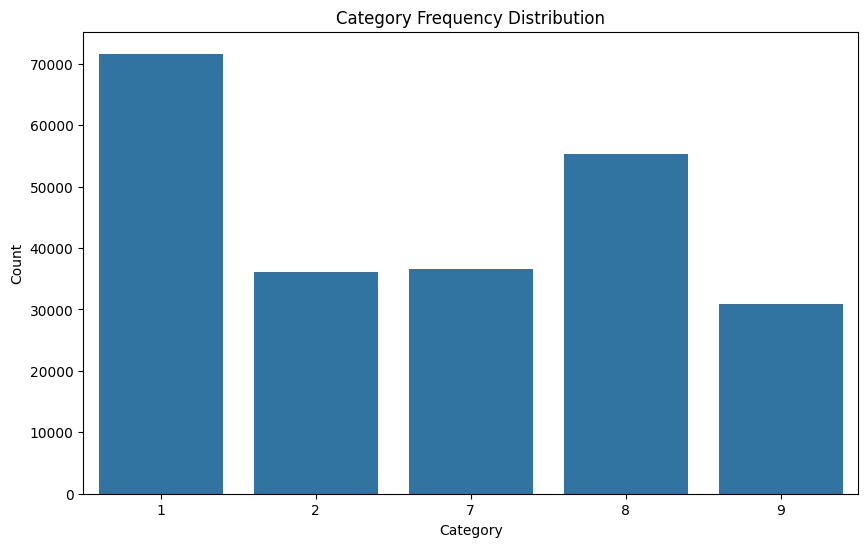

Top 5 Categories: [1, 8, 7, 2, 9]
Top 5 Count: [71645, 55387, 36616, 36064, 30835]


In [5]:
cat_df = pd.DataFrame(category_counter.items(), columns=["Category", "Count"])
cat_df = cat_df.sort_values("Count", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Category", y="Count", data=cat_df)
plt.title("Category Frequency Distribution")
plt.show()

top5 = cat_df.head(5)["Category"].tolist()
count = cat_df.head(5)["Count"].to_list()
print("Top 5 Categories:", top5)
print("Top 5 Count:", count)

In [6]:
# Load class name mapping from DeepFashion2 dataset
class_mapping = {}

for file in json_files:
    with open(os.path.join(ANNO_DIR, file)) as f:
        data = json.load(f)
    
    for key in data.keys():
        if key.startswith("item"):
            item = data[key]
            cat_id = item["category_id"]
            cat_name = item.get("category_name", "Unknown")
            class_mapping[cat_id] = cat_name

# Display class name mapping
class_mapping_df = pd.DataFrame(list(class_mapping.items()), columns=["Category_ID", "Category_Name"])
class_mapping_df = class_mapping_df.sort_values("Category_ID")
print(class_mapping_df)

   Category_ID     Category_Name
1            1  short sleeve top
2            2   long sleeve top
4            7            shorts
0            8          trousers
3            9             skirt


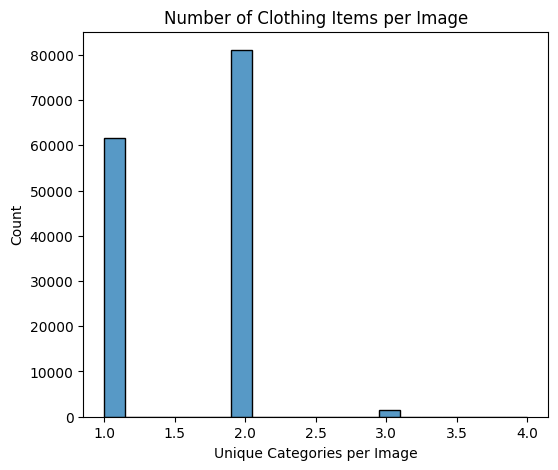

In [7]:
plt.figure(figsize=(6,5))
sns.histplot(image_label_counts, bins=20)
plt.title("Number of Clothing Items per Image")
plt.xlabel("Unique Categories per Image")
plt.show()

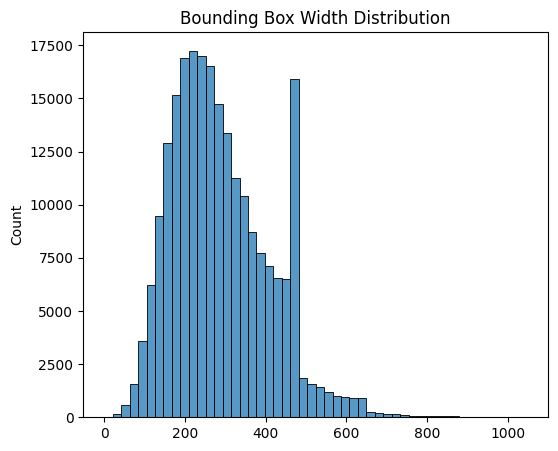

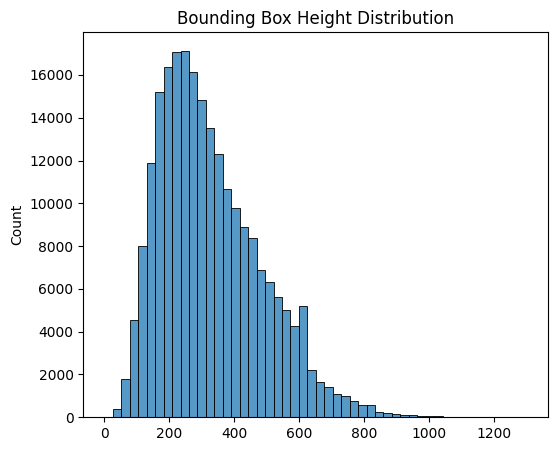

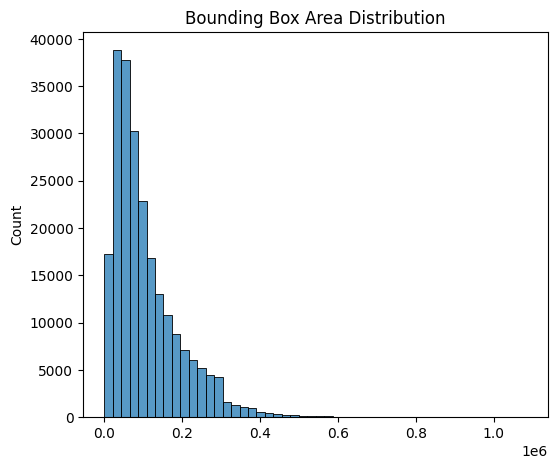

In [8]:
plt.figure(figsize=(6,5))
sns.histplot(bbox_widths, bins=50)
plt.title("Bounding Box Width Distribution")
plt.show()

plt.figure(figsize=(6,5))
sns.histplot(bbox_heights, bins=50)
plt.title("Bounding Box Height Distribution")
plt.show()

plt.figure(figsize=(6,5))
sns.histplot(bbox_areas, bins=50)
plt.title("Bounding Box Area Distribution")
plt.show()

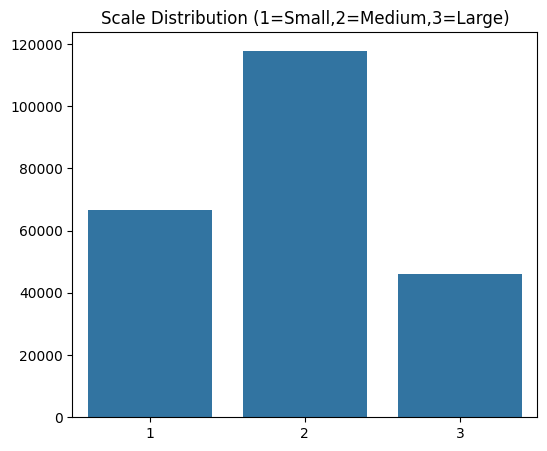

In [9]:
plt.figure(figsize=(6,5))
sns.barplot(x=list(scale_counter.keys()), y=list(scale_counter.values()))
plt.title("Scale Distribution (1=Small,2=Medium,3=Large)")
plt.show()

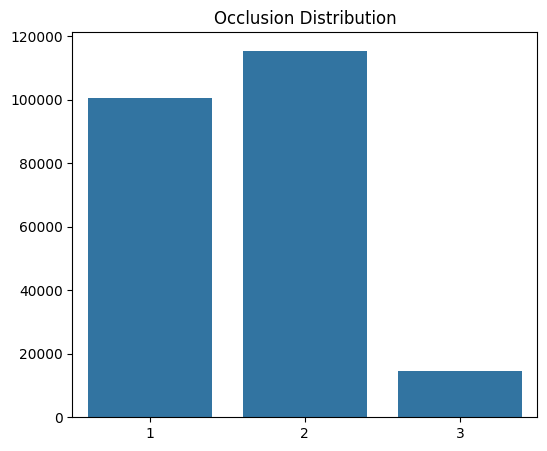

In [10]:
plt.figure(figsize=(6,5))
sns.barplot(x=list(occlusion_counter.keys()), y=list(occlusion_counter.values()))
plt.title("Occlusion Distribution")
plt.show()

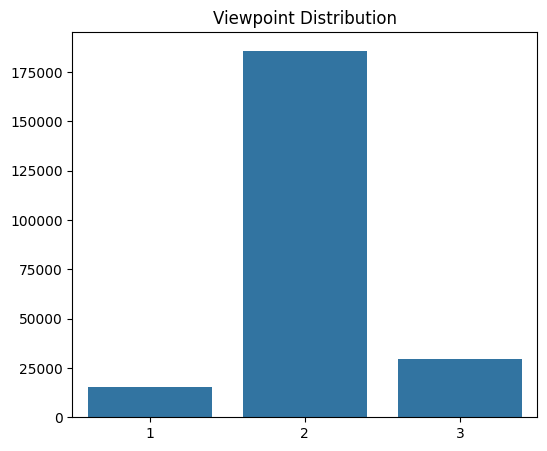

In [11]:
plt.figure(figsize=(6,5))
sns.barplot(x=list(viewpoint_counter.keys()), y=list(viewpoint_counter.values()))
plt.title("Viewpoint Distribution")
plt.show()

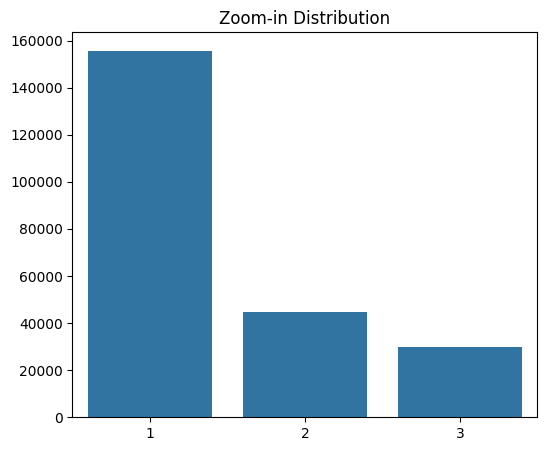

In [12]:
plt.figure(figsize=(6,5))
sns.barplot(x=list(zoom_counter.keys()), y=list(zoom_counter.values()))
plt.title("Zoom-in Distribution")
plt.show()

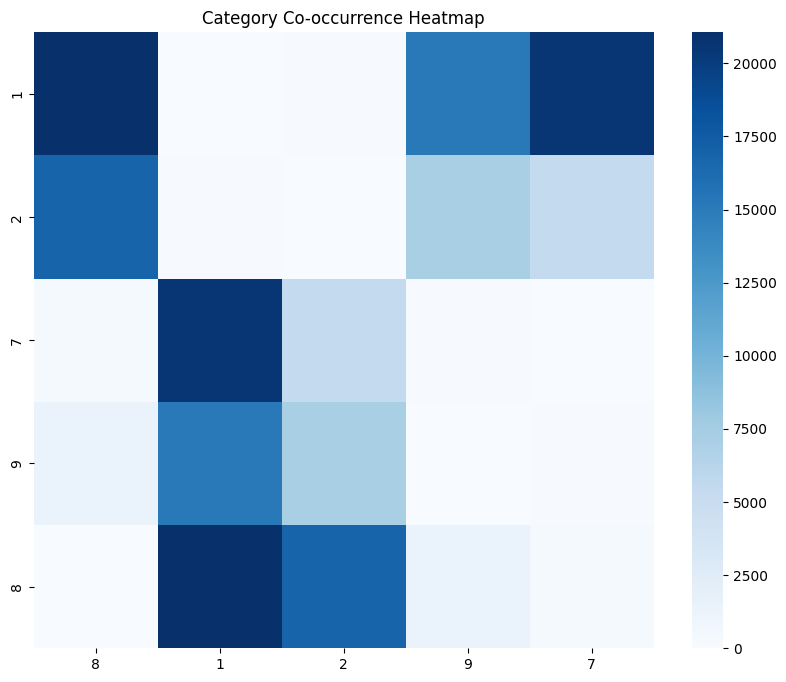

In [14]:
co_mat = pd.DataFrame(co_occurrence).fillna(0)

plt.figure(figsize=(10,8))
sns.heatmap(co_mat, cmap="Blues")
plt.title("Category Co-occurrence Heatmap")
plt.show()